<a href="https://colab.research.google.com/github/Zainsiddiqui555/-AI-Lab-assistant-updated/blob/main/DL_Assi_01_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images shape:", X_train.shape)   # (60000, 28, 28)
print("Testing images shape :", X_test.shape)    # (10000, 28, 28)
print("Training labels shape:", y_train.shape)
print("Testing labels shape :", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape: (60000, 28, 28)
Testing images shape : (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape : (10000,)


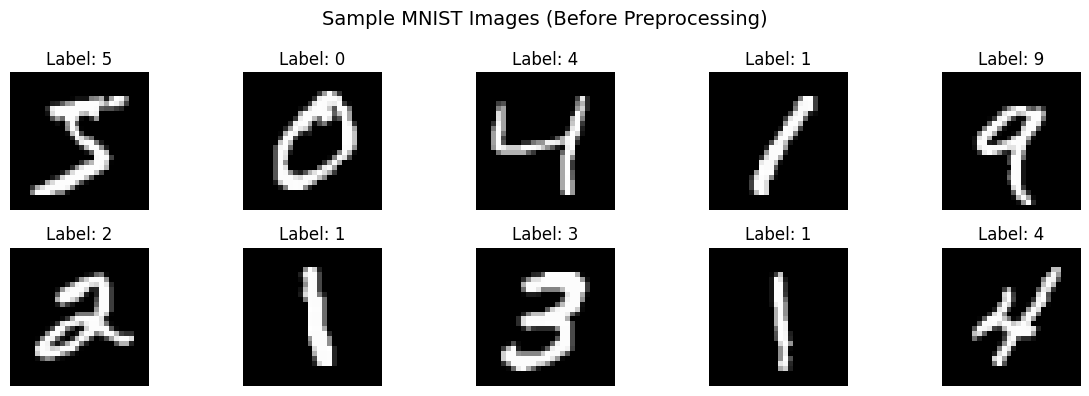

Sample images saved.


In [ ]:

# ============================================================
# STEP 3: EXPLORE THE DATASET (Sample Visualization)
# ============================================================
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample MNIST Images (Before Preprocessing)", fontsize=14)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=100)
plt.show()
print("Sample images saved.")


In [ ]:


# ============================================================
# STEP 4: PREPROCESSING
# ============================================================

# 4a. Normalize pixel values: 0–255 → 0.0–1.0
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# 4b. Flatten: 28x28 → 784 (for Dense/fully-connected layers)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

print("Flattened training shape:", X_train_flat.shape)   # (60000, 784)
print("Flattened testing shape :", X_test_flat.shape)    # (10000, 784)


Flattened training shape: (60000, 784)
Flattened testing shape : (10000, 784)


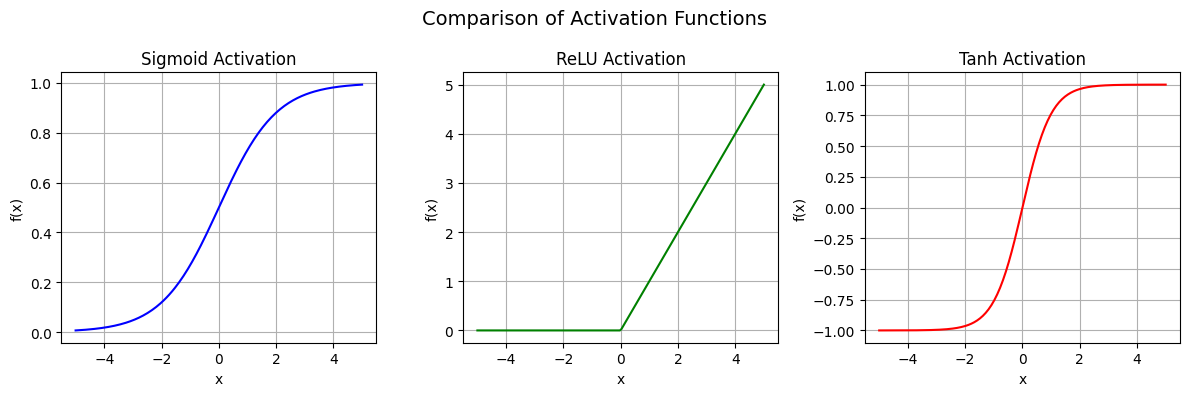

Activation function plots saved.


In [ ]:

# ============================================================
# STEP 5: EXPLORE ACTIVATION FUNCTIONS (Experiment 1)
# ============================================================

x = np.linspace(-5, 5, 200)

sigmoid = 1 / (1 + np.exp(-x))
relu    = np.maximum(0, x)
tanh    = np.tanh(x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid, color='blue')
plt.title("Sigmoid Activation")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, relu, color='green')
plt.title("ReLU Activation")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, tanh, color='red')
plt.title("Tanh Activation")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True)

plt.suptitle("Comparison of Activation Functions", fontsize=14)
plt.tight_layout()
plt.savefig("activation_functions.png", dpi=100)
plt.show()
print("Activation function plots saved.")



In [ ]:

# ============================================================
# STEP 6: BUILD THE NEURAL NETWORK (Main Model)
# ============================================================
"""
Architecture:
  Input Layer  : 784 nodes (flattened 28x28 image)
  Hidden Layer 1: 128 neurons + ReLU
  Hidden Layer 2: 64  neurons + ReLU
  Output Layer :  10 neurons  + Softmax (one per digit class)
"""

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,), name='Hidden_Layer_1'),
    Dense(64,  activation='relu',                     name='Hidden_Layer_2'),
    Dense(10,  activation='softmax',                  name='Output_Layer')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


# ============================================================
# STEP 7: COMPILE THE MODEL
# ============================================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:

# ============================================================
# STEP 8: TRAIN THE MODEL
# ============================================================
history = model.fit(
    X_train_flat, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,   # 10% of training data used for validation
    verbose=1
)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9234 - loss: 0.2600 - val_accuracy: 0.9675 - val_loss: 0.1129
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9651 - loss: 0.1133 - val_accuracy: 0.9742 - val_loss: 0.0947
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9767 - loss: 0.0770 - val_accuracy: 0.9735 - val_loss: 0.0953
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9820 - loss: 0.0590 - val_accuracy: 0.9773 - val_loss: 0.0856
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9850 - loss: 0.0457 - val_accuracy: 0.9788 - val_loss: 0.0887
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9877 - loss: 0.0383 - val_accuracy: 0.9788 - val_loss: 0.0837
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9903 - loss: 0.0295 - val_accuracy: 0.9767 - val_loss: 0.0845
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9908 - loss: 0.0271 - 

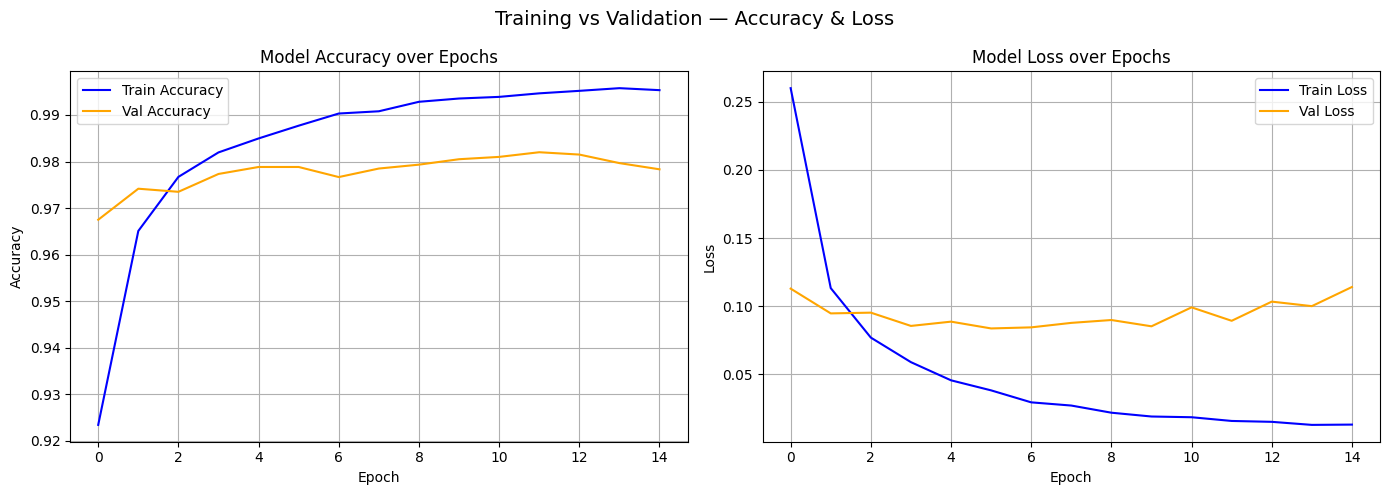

Accuracy/Loss graphs saved.


In [ ]:


# ============================================================
# STEP 9: VISUALIZE TRAINING — ACCURACY & LOSS GRAPHS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Training vs Validation — Accuracy & Loss", fontsize=14)
plt.tight_layout()
plt.savefig("accuracy_loss_graphs.png", dpi=100)
plt.show()
print("Accuracy/Loss graphs saved.")

In [ ]:

# ============================================================
# STEP 10: EVALUATE ON TEST SET
# ============================================================
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nTest Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")



Test Accuracy : 97.82%
Test Loss     : 0.1076


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


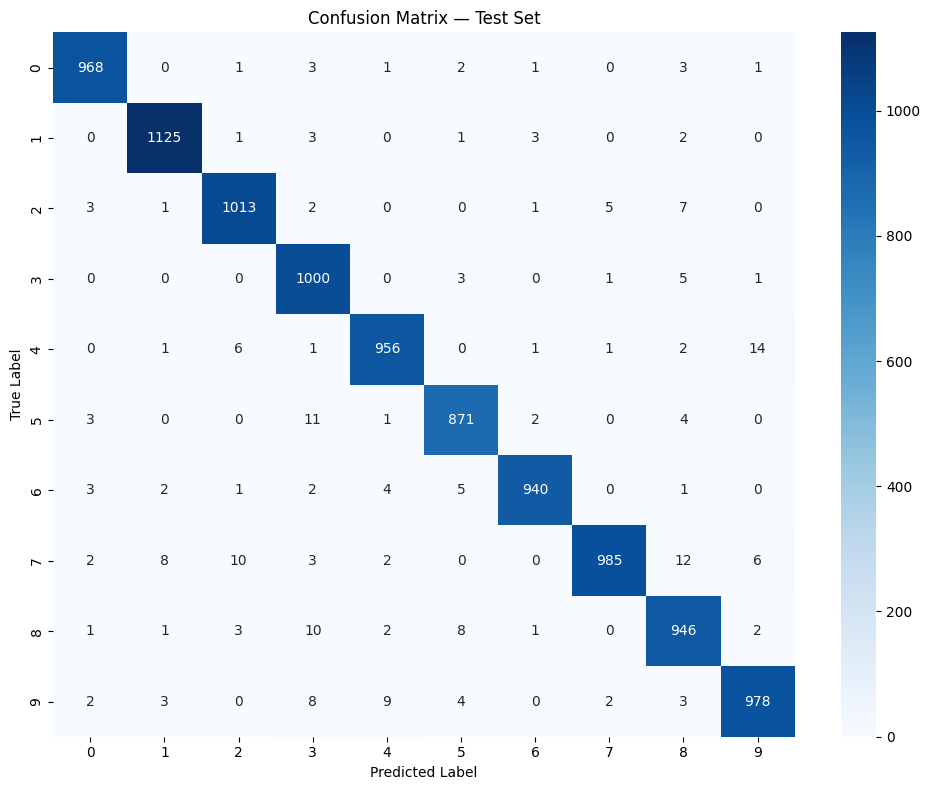

Confusion matrix saved.

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.99      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.96      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:



# ============================================================
# STEP 11: CONFUSION MATRIX
# ============================================================
y_pred_probs = model.predict(X_test_flat)
y_pred       = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()
print("Confusion matrix saved.")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Total Misclassified: 218 / 10000


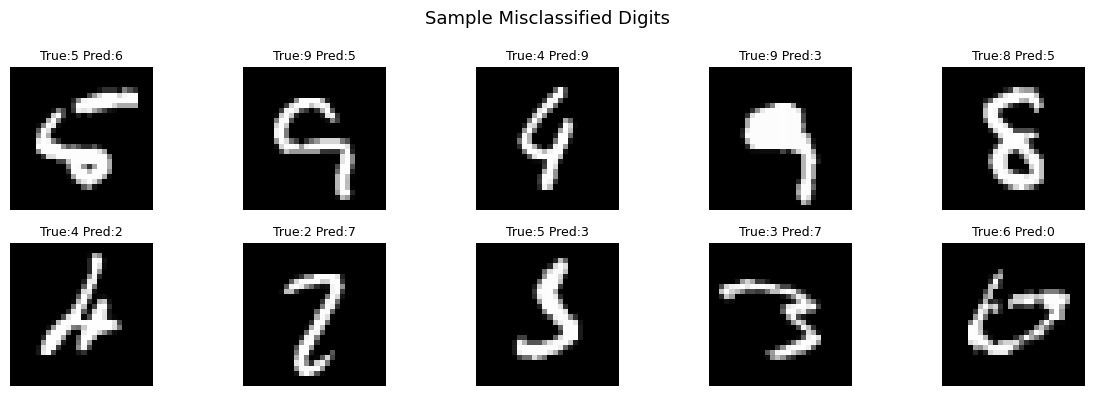

In [ ]:

# ============================================================
# STEP 12: MISCLASSIFICATION ANALYSIS
# ============================================================
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"\nTotal Misclassified: {len(misclassified_idx)} / {len(y_test)}")

plt.figure(figsize=(12, 4))
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True:{y_test[idx]} Pred:{y_pred[idx]}", fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Misclassified Digits", fontsize=13)
plt.tight_layout()
plt.savefig("misclassified_samples.png", dpi=100)
plt.show()

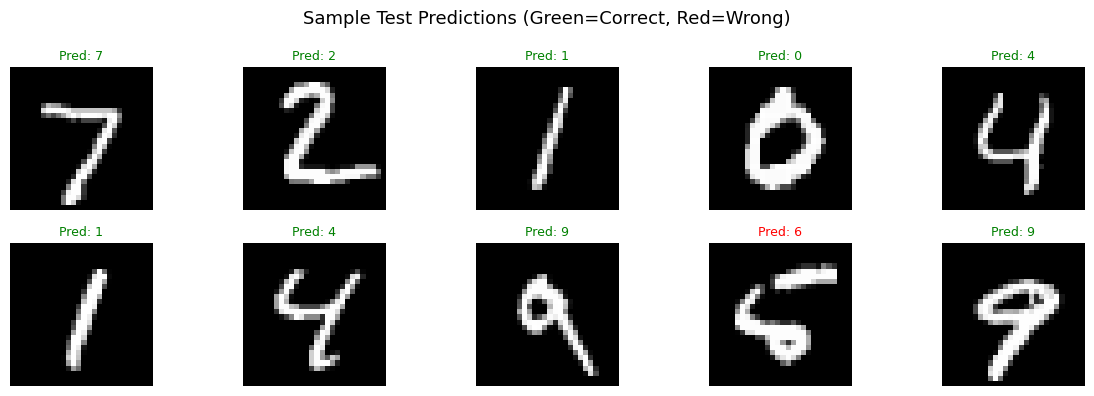

In [ ]:

# ============================================================
# STEP 13: SAMPLE PREDICTIONS VISUALIZATION
# ============================================================
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"Pred: {y_pred[i]}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Test Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=100)
plt.show()

In [ ]:

# ============================================================
# STEP 14: OVERFITTING ANALYSIS (Without Dropout)
# ============================================================
"""
If training accuracy >> validation accuracy → OVERFITTING
If both are close → GOOD GENERALIZATION
"""

train_acc_final = history.history['accuracy'][-1]
val_acc_final   = history.history['val_accuracy'][-1]
gap             = train_acc_final - val_acc_final

print(f"\nOverfitting Analysis:")
print(f"  Final Train Accuracy      : {train_acc_final * 100:.2f}%")
print(f"  Final Validation Accuracy : {val_acc_final * 100:.2f}%")
print(f"  Gap (Overfit Indicator)   : {gap * 100:.2f}%")
if gap > 0.05:
    print("  ⚠ Model may be overfitting. Consider adding Dropout.")
else:
    print("  ✓ Model generalizes well.")



Overfitting Analysis:
  Final Train Accuracy      : 99.53%
  Final Validation Accuracy : 97.83%
  Gap (Overfit Indicator)   : 1.70%
  ✓ Model generalizes well.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ HD1 (Dense)                     │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HD2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8825 - loss: 0.3846 - val_accuracy: 0.9648 - val_loss: 0.1215
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9401 - loss: 0.1990 - val_accuracy: 0.9710 - val_loss: 0.0959
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9527 - loss: 0.1555 - val_accuracy: 0.9743 - val_loss: 0.0868
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9599 - loss: 0.1323 - val_accuracy: 0.9778 - val_loss: 0.0744
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9631 - loss: 0.1169 - val_accuracy: 0.9772 - val_loss: 0.0754
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9672 - loss: 0.1074 - val_accuracy: 0.9795 - val_loss: 0.0639
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9688 - loss: 0.0996 - val_accuracy: 0.9783 - val_loss: 0.0706
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9718 - loss: 0.0915 -

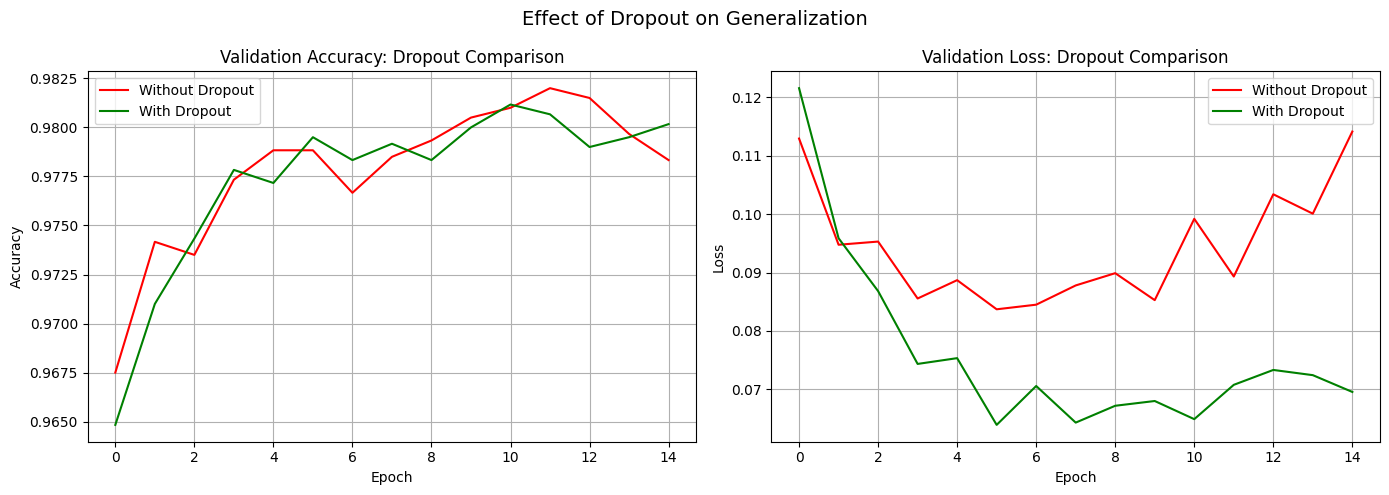

Dropout comparison saved.

Dropout Model — Test Accuracy: 97.76%


In [ ]:

# ============================================================
# STEP 15: EXPERIMENT — ADD DROPOUT (Regularization)
# ============================================================
model_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(784,), name='HD1'),
    Dropout(0.3, name='Dropout_1'),         # Drop 30% neurons randomly
    Dense(64,  activation='relu',            name='HD2'),
    Dropout(0.2, name='Dropout_2'),         # Drop 20% neurons randomly
    Dense(10,  activation='softmax',         name='Output')
])

model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_dropout.summary()

history_dropout = model_dropout.fit(
    X_train_flat, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Compare with vs without dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['val_accuracy'],        label='Without Dropout', color='red')
axes[0].plot(history_dropout.history['val_accuracy'], label='With Dropout',    color='green')
axes[0].set_title('Validation Accuracy: Dropout Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['val_loss'],        label='Without Dropout', color='red')
axes[1].plot(history_dropout.history['val_loss'], label='With Dropout',    color='green')
axes[1].set_title('Validation Loss: Dropout Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Effect of Dropout on Generalization", fontsize=14)
plt.tight_layout()
plt.savefig("dropout_comparison.png", dpi=100)
plt.show()
print("Dropout comparison saved.")

# Final dropout model accuracy
dl_loss, dl_acc = model_dropout.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nDropout Model — Test Accuracy: {dl_acc * 100:.2f}%")



Activation: sigmoid    → Test Accuracy: 97.18%
Activation: relu       → Test Accuracy: 97.56%
Activation: tanh       → Test Accuracy: 97.46%


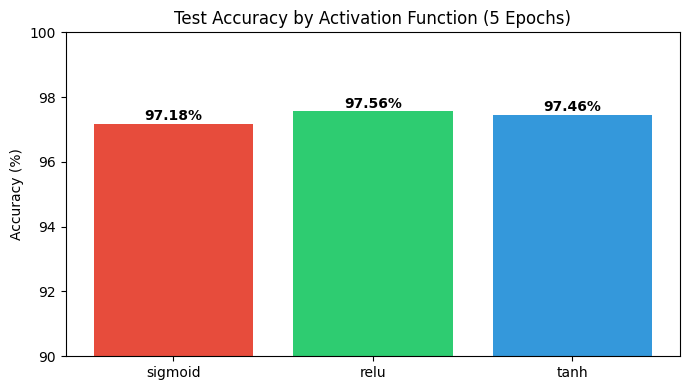

In [ ]:

# ============================================================
# STEP 16: EXPERIMENT — DIFFERENT ACTIVATION FUNCTIONS
# ============================================================
results = {}

for activation in ['sigmoid', 'relu', 'tanh']:
    m = Sequential([
        Dense(128, activation=activation, input_shape=(784,)),
        Dense(64,  activation=activation),
        Dense(10,  activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_flat, y_train, epochs=5, batch_size=32,
              validation_split=0.1, verbose=0)
    _, acc = m.evaluate(X_test_flat, y_test, verbose=0)
    results[activation] = round(acc * 100, 2)
    print(f"Activation: {activation:10s} → Test Accuracy: {acc*100:.2f}%")

# Bar chart comparison
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values(), color=['#e74c3c', '#2ecc71', '#3498db'])
plt.title("Test Accuracy by Activation Function (5 Epochs)")
plt.ylabel("Accuracy (%)")
plt.ylim(90, 100)
for k, v in results.items():
    plt.text(k, v + 0.1, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("activation_comparison.png", dpi=100)
plt.show()

1 Hidden Layer: 97.81%
2 Hidden Layers: 97.53%
3 Hidden Layers: 97.35%


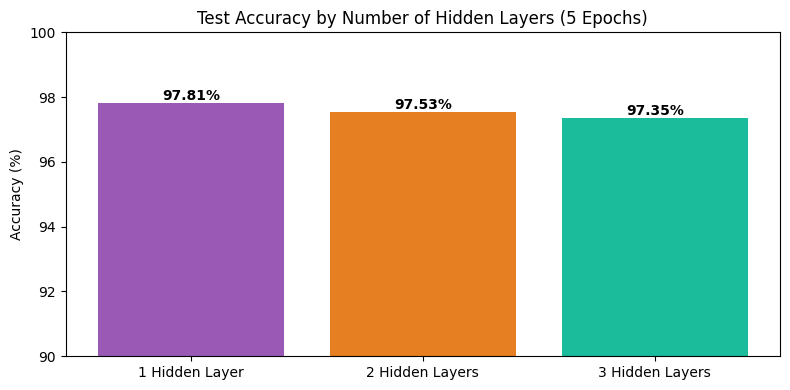

In [ ]:

# ============================================================
# STEP 17: EXPERIMENT — DIFFERENT NUMBER OF HIDDEN LAYERS
# ============================================================
layer_configs = {
    "1 Hidden Layer" : [Sequential([Dense(128,'relu',input_shape=(784,)), Dense(10,'softmax')])],
    "2 Hidden Layers": [Sequential([Dense(128,'relu',input_shape=(784,)), Dense(64,'relu'), Dense(10,'softmax')])],
    "3 Hidden Layers": [Sequential([Dense(128,'relu',input_shape=(784,)), Dense(64,'relu'), Dense(32,'relu'), Dense(10,'softmax')])]
}

layer_results = {}
for name, (m,) in layer_configs.items():
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_train_flat, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=0)
    _, acc = m.evaluate(X_test_flat, y_test, verbose=0)
    layer_results[name] = round(acc * 100, 2)
    print(f"{name}: {acc*100:.2f}%")

plt.figure(figsize=(8, 4))
plt.bar(layer_results.keys(), layer_results.values(), color=['#9b59b6', '#e67e22', '#1abc9c'])
plt.title("Test Accuracy by Number of Hidden Layers (5 Epochs)")
plt.ylabel("Accuracy (%)"); plt.ylim(90, 100)
for k, v in layer_results.items():
    plt.text(k, v + 0.1, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("layer_comparison.png", dpi=100)
plt.show()



Epochs:   3 → Test Accuracy: 97.20%
Epochs:   5 → Test Accuracy: 98.01%
Epochs:  10 → Test Accuracy: 97.86%
Epochs:  15 → Test Accuracy: 97.82%


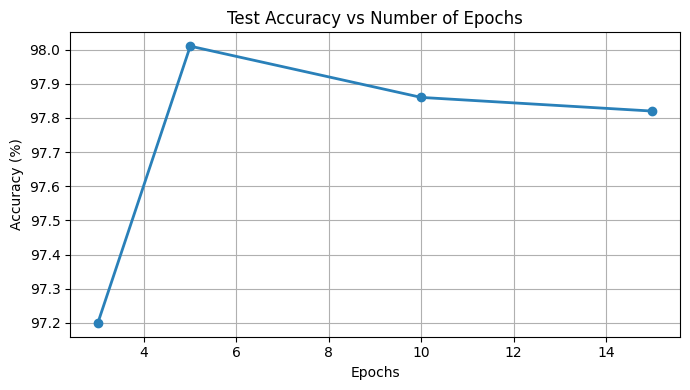

In [ ]:

# ============================================================
# STEP 18: EXPERIMENT — DIFFERENT NUMBER OF EPOCHS
# ============================================================
epoch_tests = [3, 5, 10, 15]
epoch_results = []

for ep in epoch_tests:
    m = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64,  activation='relu'),
        Dense(10,  activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_train_flat, y_train, epochs=ep, batch_size=32, verbose=0)
    _, acc = m.evaluate(X_test_flat, y_test, verbose=0)
    epoch_results.append(round(acc * 100, 2))
    print(f"Epochs: {ep:3d} → Test Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(7, 4))
plt.plot(epoch_tests, epoch_results, marker='o', color='#2980b9', linewidth=2)
plt.title("Test Accuracy vs Number of Epochs")
plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig("epoch_comparison.png", dpi=100)
plt.show()


In [ ]:

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("  FINAL RESULTS SUMMARY")
print("="*60)
print(f"  Baseline Model Test Accuracy  : {test_accuracy * 100:.2f}%")
print(f"  Dropout Model Test Accuracy   : {dl_acc * 100:.2f}%")
print(f"\n  Activation Function Results:")
for k, v in results.items():
    print(f"    {k:10s}: {v}%")
print(f"\n  Layer Configuration Results:")
for k, v in layer_results.items():
    print(f"    {k}: {v}%")
print(f"\n  Epoch Experiment Results:")
for ep, acc in zip(epoch_tests, epoch_results):
    print(f"    {ep:2d} epochs: {acc}%")
print("="*60)
print("  All graphs saved as PNG files.")
print("="*60)



  FINAL RESULTS SUMMARY
  Baseline Model Test Accuracy  : 97.82%
  Dropout Model Test Accuracy   : 97.76%

  Activation Function Results:
    sigmoid   : 97.18%
    relu      : 97.56%
    tanh      : 97.46%

  Layer Configuration Results:
    1 Hidden Layer: 97.81%
    2 Hidden Layers: 97.53%
    3 Hidden Layers: 97.35%

  Epoch Experiment Results:
     3 epochs: 97.2%
     5 epochs: 98.01%
    10 epochs: 97.86%
    15 epochs: 97.82%
  All graphs saved as PNG files.


In [ ]:
# Upload image in Colab
from google.colab import files
uploaded = files.upload()   # select your image file

Saving hand writen.png to hand writen (1).png


Digit 1: Predicted Digit: 5, Confidence: 100.00%
Digit 2: Predicted Digit: 0, Confidence: 99.99%
Digit 3: Predicted Digit: 5, Confidence: 66.24%
Digit 4: Predicted Digit: 1, Confidence: 98.06%
Digit 5: Predicted Digit: 3, Confidence: 68.65%
Digit 6: Predicted Digit: 2, Confidence: 88.13%
Digit 8: Predicted Digit: 3, Confidence: 89.33%
Digit 9: Predicted Digit: 3, Confidence: 100.00%
Digit 11: Predicted Digit: 5, Confidence: 99.19%
Digit 12: Predicted Digit: 8, Confidence: 68.27%


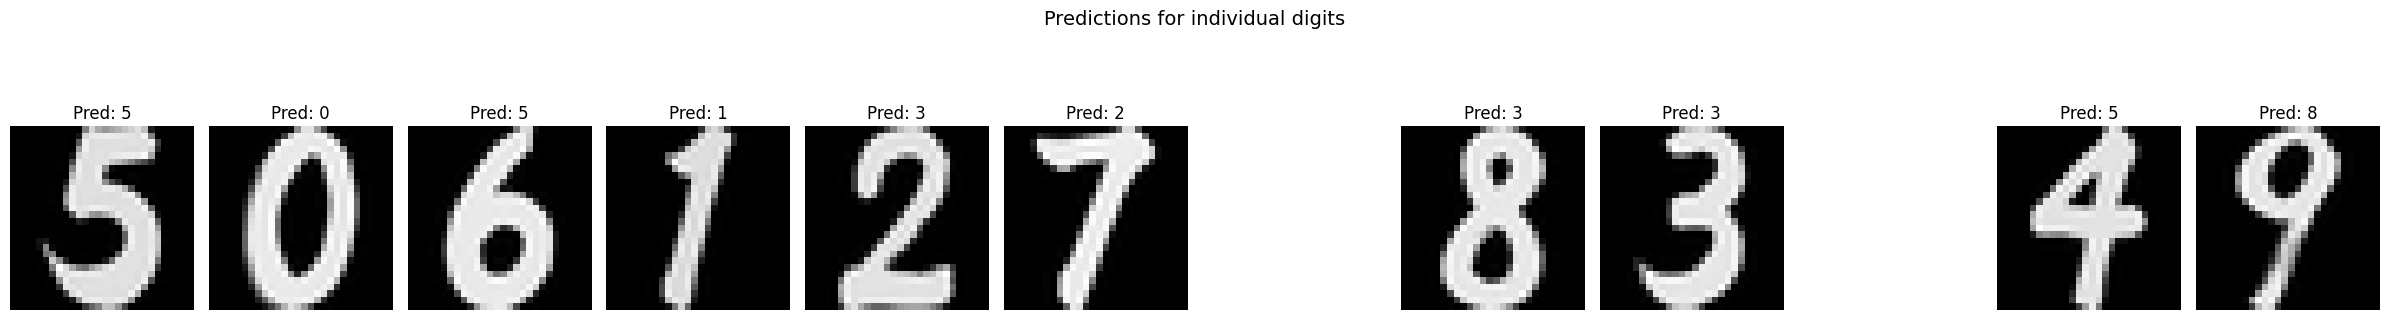

In [ ]:
# ============================================================
# PREDICT CUSTOM IMAGES (potentially multiple digits)
# ============================================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2 # OpenCV for image processing
import os

image_filename = "hand writen (1).png"

# Check if the image file exists
if not os.path.exists(image_filename):
    print(f"Error: The file '{image_filename}' was not found. Please upload it or check the filename.")
else:
    # Load your image
    img_original = Image.open(image_filename)

    # Convert to grayscale
    img_gray = img_original.convert("L")

    # Convert to numpy array
    img_array = np.array(img_gray)

    # Invert the image (MNIST has white digits on black background)
    # If your image has black digits on white background, this step is crucial.
    # We can perform a simple check or assume white background based on context.
    # For handwritten digits, often white background, black digits from scanning/drawing.
    # MNIST expects white digits, black background.
    # Let's assume input is black digit on white background, so invert.
    img_inverted = 255 - img_array

    # Apply a binary threshold to get a clear black and white image
    # Use Otsu's method to automatically find the optimal threshold value
    _, img_threshold = cv2.threshold(img_inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Find contours (potential digits)
    contours, _ = cv2.findContours(img_threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("No digits found in the image. Please ensure digits are clearly visible.")
    else:
        # Sort contours from left to right (assuming digits are written horizontally)
        contours = sorted(contours, key=lambda ctr: cv2.boundingRect(ctr)[0])

        plt.figure(figsize=(len(contours) * 2, 4))
        for i, contour in enumerate(contours):
            x, y, w, h = cv2.boundingRect(contour)

            # Filter out very small contours that are likely noise
            if w < 10 or h < 10:  # Adjust these thresholds if needed
                continue

            # Extract the digit region
            digit_img = img_inverted[y:y+h, x:x+w]

            # Pad the digit to make it square and center it
            max_dim = max(w, h)
            pad_x = (max_dim - w) // 2
            pad_y = (max_dim - h) // 2
            padded_digit = np.pad(digit_img, ((pad_y, max_dim - h - pad_y), (pad_x, max_dim - w - pad_x)), 'constant', constant_values=0)

            # Resize to 28x28 (MNIST size)
            digit_resized = Image.fromarray(padded_digit).resize((28, 28), Image.LANCZOS)
            digit_array = np.array(digit_resized)

            # Normalize
            digit_normalized = digit_array / 255.0

            # Flatten to 784
            digit_flat = digit_normalized.reshape(1, 784)

            # Predict
            prediction = model.predict(digit_flat, verbose=0)
            predicted_digit = np.argmax(prediction)

            # Show result
            plt.subplot(1, len(contours), i + 1)
            plt.imshow(digit_normalized, cmap='gray')
            plt.title(f"Pred: {predicted_digit}", fontsize=12)
            plt.axis('off')

            print(f"Digit {i+1}: Predicted Digit: {predicted_digit}, Confidence: {prediction[0][predicted_digit]*100:.2f}%")

        plt.suptitle("Predictions for individual digits", fontsize=14)
        plt.tight_layout()
        plt.show()
